In [1]:
import uproot
import matplotlib.pyplot as plt
plt.style.use("/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_GUNDAM/gundam-icarus/style.mplstyle")
import numpy as np
from IPython.display import display

In [4]:
def plot_cross_section(filename, hist_path, xlabel, ylabel, bin_edges_labels,
                       title_line1=None, label=None,
                       figsize=(5, 4), output_name=None, pot='POT'):
    """
    Plot cross-section data from a ROOT file with error bars.

    Parameters
    ----------
    filename : str
        Path to the ROOT file
    hist_path : str
        Path to the histogram within the ROOT file (e.g., "gundam/calcXsec/throws/histograms/TrueDeltaPT_XS_TH1D;1")
    xlabel : str
        Label for the x-axis (use raw string with LaTeX, e.g., r'True $\delta_{pT}$ [GeV]')
    ylabel : str
        Label for the y-axis (use raw string with LaTeX, e.g., r'$\frac{d\sigma}{dp_T}$ $\left[\frac{cm^2}{GeV/c^2}\right]$')
    bin_edges_labels : list
        List of bin edge values to display on x-axis (e.g., [0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    title_line1 : str, optional
        First line of title (e.g., "ICARUS · NuMI Data (10% Run 2)")
    figsize : tuple, optional
        Figure size (width, height). Default is (5, 4)
    output_name : str, optional
        Output filename for saving the plot. If None, uses the histogram name. Default is None

    Returns
    -------
    fig, ax : matplotlib figure and axis objects
    """
    # Open the ROOT file
    file = uproot.open(filename)

    # Navigate to the histogram
    hist = file[hist_path]

    # Extract bin values and errors
    bin_values = hist.values()*1e40
    bin_errors = hist.errors()*1e40

    # Calculate bin centers from provided bin edges
    bin_edges_array = np.array(bin_edges_labels)
    bin_centers = (bin_edges_array[:-1] + bin_edges_array[1:]) / 2
    bin_widths = np.diff(bin_edges_array)

    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)

    # Plot using errorbar
    ax.errorbar(bin_centers,
                bin_values,
                xerr=bin_widths / 2,  # Half bin width for symmetric error bars
                #yerr=bin_errors,
                fmt='o',
                markersize=7,
                markerfacecolor='black',
                markeredgecolor='black',
                color='black',
                capsize=4,
                capthick=1.5,
                elinewidth=1.5,
                label=label,
                linewidth=2)

    # Set axis labels
    ax.set_xlabel(xlabel, fontsize=12, weight='bold')
    ax.set_ylabel(ylabel, fontsize=12, weight='bold')

    # Set axis limits
    ax.set_xlim(bin_edges_array[0], bin_edges_array[-1])
    y_min = 0
    y_max = np.max(bin_values + bin_errors) * 1.2
    ax.set_ylim(y_min, y_max)

    # Set x-axis ticks at bin edges
    #ax.set_xticks(bin_edges_array)
    #ax.set_xticklabels([f'{x:.1f}' for x in bin_edges_array], fontsize=10)

    # Set tick parameters
    ax.tick_params(axis='both', which='major',
                   labelsize=12,
                   size=8,
                   width=2,
                   direction='in')

    # Enable minor ticks
    ax.minorticks_on()
    ax.tick_params(axis='y', which='minor',
                   size=4,
                   width=1,
                   direction='in')
    ax.tick_params(axis='x', which='minor',
                   size=4,
                   width=1,
                   direction='in')

    # Add two-line title if provided (RIGHT-aligned)
    if title_line1:
        title_text = ""
        if title_line1:
            title_text += title_line1

        yrange = ax.get_ylim()
        usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0.0*(yrange[1] - yrange[0])
        xrange = ax.get_xlim()
        usex = xrange[0] + 0.01*(xrange[1] - xrange[0]) + 0.0*(xrange[1] - xrange[0])
        color = 'chocolate' if 'data' in title_line1.lower() else 'blue'
        ax.text(x=usex, y=usey, s=title_line1, fontsize=10, color=color, verticalalignment='bottom')
        usex_right = xrange[1] - 0.025*(xrange[1] - xrange[0])
        ax.text(x=usex_right, y=usey, s=pot, fontsize=10, color="black",
                verticalalignment='bottom', horizontalalignment='right')

    # Force font family on tick labels after formatting
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily('sans-serif')

    # Also set font for the offset text (scientific notation exponent)
    ax.yaxis.get_offset_text().set_fontfamily('sans-serif')
    ax.xaxis.get_offset_text().set_fontfamily('sans-serif')

    # Grid
    ax.grid(True, alpha=0.3)

    # Add legend
    ax.legend(loc='best', fontsize=10, framealpha=0.9)

    # Save the plot
    if output_name is None:
        output_name = f"{hist.name}_matplotlib.png"
    #plt.savefig(output_name, dpi=300, bbox_inches='tight')

    # Return the plot
    return fig, ax

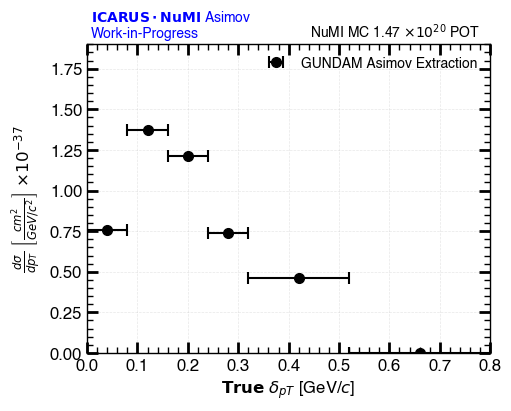

In [8]:
fig_xs, ax_xs = plot_cross_section(
        filename='/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_GUNDAM/data/exampleXSec.root',
        hist_path="calcXsec/histograms/TrueDeltaPT_XS_TH1D;1",
        xlabel=r'$\mathbf{True}$ $\delta_{pT}$ [GeV/$c$]',
        ylabel=r'$\frac{d\sigma}{dp_T}$ $\left[\frac{cm^2}{GeV/c^2}\right]$ $\times 10^{-37}$',
        bin_edges_labels=[0.0, 0.08, 0.16, 0.24, 0.32, 0.52, 0.8],
        title_line1=r'$\bf{ICARUS \cdot NuMI}$ Asimov' + '\n' + 'Work-in-Progress',
        label="GUNDAM Asimov Extraction",
        output_name='TrueDeltaPT_XS_matplotlib.png',
        pot=r'NuMI MC 1.47 $\times 10^{20}$ POT'
)

In [9]:
def overlay_manual_cross_section(fig, ax, root_file_path, bins_mev,
                                 n_targets,
                                 flux,
                                 signal_tree_path="events/full/signal",
                                 variable_name="true_dpT",
                                 category_cuts=[0, 1, 3, 4],
                                 color='red',
                                 marker='s',
                                 label='Manual Calculation',
                                 markersize=7):
    """
    Calculate cross-section manually and overlay on existing plot.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Existing figure object from plot_cross_section
    ax : matplotlib.axes.Axes
        Existing axes object from plot_cross_section
    root_file_path : str
        Path to the ROOT file containing the signal tree
    bins_mev : list of tuples
        List of bin edges in MeV, e.g., [(0, 80), (80, 160), (160, 240), (240, 320), (320, 520), (520, 99999)]
    n_targets : float
        Number of target nucleons
    flux : float
        Neutrino flux
    signal_tree_path : str, optional
        Path to the signal tree. Default is "events/full/signal"
    variable_name : str, optional
        Variable name to bin. Default is "true_dpT"
    category_cuts : list, optional
        Category values for signal selection. Default is [0, 1, 3, 4]
    color : str, optional
        Color for manual calculation points. Default is 'red'
    marker : str, optional
        Marker style. Default is 's' (square)
    label : str, optional
        Label for legend. Default is 'Manual Calculation'
    markersize : int, optional
        Marker size. Default is 7

    Returns
    -------
    fig, ax : modified matplotlib figure and axis objects
    cross_sections : np.ndarray
        Array of calculated cross-section values (in 10^-40 cm²/GeV units for plotting)
    """
    import uproot
    import awkward as ak
    import numpy as np

    # Open ROOT file and get tree
    file = uproot.open(root_file_path)
    tree = file[signal_tree_path]

    print(f"Found tree: {signal_tree_path}")
    print(f"Number of entries: {tree.num_entries}")

    # Read branches
    arrays = tree.arrays([variable_name, "category"], library="ak")

    # Apply signal selection
    signal_mask = ak.zeros_like(arrays.category, dtype=bool)
    for cat in category_cuts:
        signal_mask = signal_mask | (arrays.category == cat)

    signal_events = arrays[signal_mask]
    print(f"Total signal events: {len(signal_events)}")
    print(f"N_targets: {n_targets:.3e}")
    print(f"Flux: {flux:.3e}")

    # Calculate cross-section per bin
    print("\n" + "="*90)
    print("Signal Events and Cross-Section per True δpT Bin")
    print("="*90)
    print(f"{'Bin Range (MeV/c)':<25} {'N_Signal':<12} {'Bin Width (MeV)':<18} {'σ (x10-37 cm²/GeV)'}")
    print("-"*90)

    cross_sections = []
    bin_centers_gev = []
    bin_widths_gev = []

    total_signal = 0
    for bin_low, bin_high in bins_mev:
        # Count events in this bin
        bin_mask = (signal_events[variable_name] >= bin_low) & (signal_events[variable_name] < bin_high)
        n_signal = int(ak.sum(bin_mask))

        # Calculate bin width in MeV
        if bin_high < 99999:
            bin_width_mev = bin_high - bin_low
            bin_width_str = f"{bin_width_mev:.0f}"

            # Calculate cross-section x 1e37: σ = N_events / (N_targets × Flux × bin_width) × 1e3 (convert MeV to GeV)
            cross_section = 1e3 *1e37 * n_signal / (n_targets * flux * bin_width_mev)
            cross_sections.append(cross_section)
            xs_str = f"{cross_section:.6e}"

            # Calculate bin center and width in GeV for plotting
            bin_center_gev = (bin_low + bin_high) / 2 / 1000
            bin_width_gev = bin_width_mev / 1000
            bin_centers_gev.append(bin_center_gev)
            bin_widths_gev.append(bin_width_gev)
        else:
            bin_width_str = "∞"
            xs_str = "N/A (infinite bin)"

        print(f"{bin_low:>6.0f} - {bin_high:<6.0f} MeV/c    {n_signal:<12} {bin_width_str:<18} {xs_str}")
        total_signal += n_signal

    print("-"*90)
    print(f"{'Total':<25} {total_signal}")
    print("="*90)

    # Convert to numpy arrays
    cross_sections = np.array(cross_sections)
    bin_centers_gev = np.array(bin_centers_gev)
    bin_widths_gev = np.array(bin_widths_gev)

    # Overlay on existing plot
    line = ax.errorbar(bin_centers_gev,
                       cross_sections,
                       xerr=bin_widths_gev / 2,
                       fmt=marker,
                       markersize=markersize,
                       markerfacecolor=color,
                       markeredgecolor=color,
                       color=color,
                       capsize=4,
                       capthick=1.5,
                       elinewidth=1.5,
                       linewidth=2,
                       label=label,
                       alpha=0.7)

    print(f"Plot line added: {line}")
    print(f"Number of lines after adding: {len(ax.lines)}")

    # Add legend
    ax.legend(loc='best', fontsize=10, framealpha=0.9)

    return fig, ax, cross_sections

Found tree: events/full/signal
Number of entries: 24109
Total signal events: 24109
N_targets: 4.608e+30
Flux: 1.075e+11

Signal Events and Cross-Section per True δpT Bin
Bin Range (MeV/c)         N_Signal     Bin Width (MeV)    σ (x10-37 cm²/GeV)
------------------------------------------------------------------------------------------
     0 - 80     MeV/c    2943         80                 7.423176e-01
    80 - 160    MeV/c    5342         80                 1.347421e+00
   160 - 240    MeV/c    4718         80                 1.190029e+00
   240 - 320    MeV/c    2894         80                 7.299583e-01
   320 - 520    MeV/c    4491         200                4.531089e-01
   520 - 800    MeV/c    2774         280                1.999116e-01
------------------------------------------------------------------------------------------
Total                     23162
Plot line added: <ErrorbarContainer object of 3 artists>
Number of lines after adding: 6


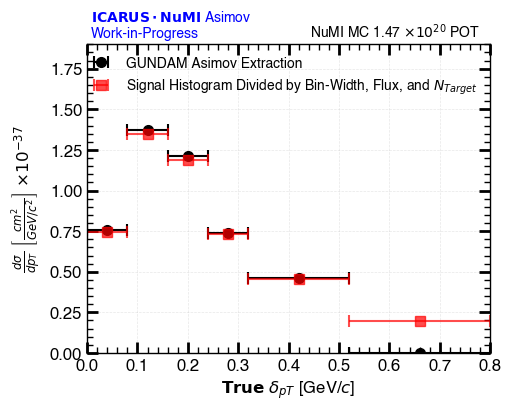

In [10]:
bins_mev = [(0, 80), (80, 160), (160, 240), (240, 320), (320, 520), (520, 800)]

# Overlay manual calculation
fig, ax, xs = overlay_manual_cross_section(
    fig=fig_xs,
    ax=ax_xs,
    root_file_path="/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_gundam.root",
    bins_mev=bins_mev,
    n_targets=4.6079073e30,
    flux=1.075491e+11,
    color='red',
    marker='s',
    label=r'Signal Histogram Divided by Bin-Width, Flux, and $N_{Target}$'
)
display(fig)